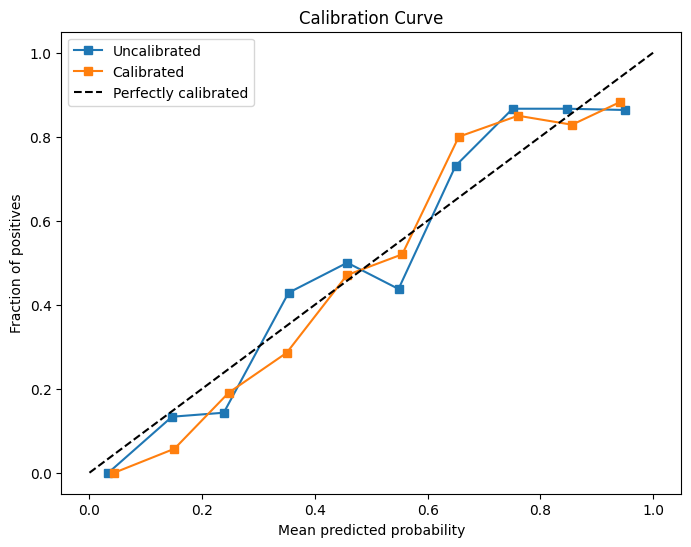

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Örnek veri seti (churn gibi ikili sınıf)
X, y = make_classification(n_samples=1000, n_features=20,
                           n_informative=10, n_redundant=5,
                           random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model: Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

# Calibrated model (Platt Scaling)
calibrated_lr = CalibratedClassifierCV(lr, method='sigmoid', cv= 5)
calibrated_lr.fit(X_train, y_train)

# Tahmin olasılıkları
probs_uncal = lr.predict_proba(X_test)[:, 1]
probs_cal = calibrated_lr.predict_proba(X_test)[:, 1]

# Calibration curve
fraction_of_positives_uncal, mean_predicted_value_uncal = calibration_curve(y_test, probs_uncal, n_bins=10)
fraction_of_positives_cal, mean_predicted_value_cal = calibration_curve(y_test, probs_cal, n_bins=10)

# Görselleştirme
plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value_uncal, fraction_of_positives_uncal, "s-", label="Uncalibrated")
plt.plot(mean_predicted_value_cal, fraction_of_positives_cal, "s-", label="Calibrated")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve")
plt.legend()
plt.show()